<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIM_Module_6_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 6 Project: Regression analysis on a COVID-dataset


In this project, we will use the concepts of regression and regularization we have learnt to predict early Covid-19 cases. We shall use linear regression, polynomial regression and ridge regression to obtain a reasonably good estimate of the future cases. Try experimenting with hyperparameters to obtain better results.

## Data Analysis

### 1. **Load the data** into a pandas dataframe.

In [3]:
# Imports
import pandas as pd
import numpy  as np
import scipy.integrate

from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 8

import copy
from   sklearn.metrics       import mean_squared_error, mean_absolute_error
from   sklearn.linear_model  import LinearRegression, BayesianRidge, Ridge
from   sklearn.tree          import DecisionTreeRegressor
from   sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [4]:
path = "https://raw.githubusercontent.com/PranavTadimeti/Regression_Project/main/covid_19_data.csv"
df_orig = pd.read_csv(path)
print("Dataset Shape:", df_orig.shape)
print("\nFirst 10 Rows:")
print(df_orig.head(10))
print("\nColumn Names:")
print(df_orig.columns)

Dataset Shape: (10671, 8)

First 10 Rows:
   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   
5    6      01/22/2020      Guangdong  Mainland China  1/22/2020 17:00   
6    7      01/22/2020        Guangxi  Mainland China  1/22/2020 17:00   
7    8      01/22/2020        Guizhou  Mainland China  1/22/2020 17:00   
8    9      01/22/2020         Hainan  Mainland China  1/22/2020 17:00   
9   10      01/22/2020          Hebei  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3      

### 2. Create a new dataframe which counts the cumulative total number of cases, the cumulative total number of deaths, and also  cumulative total number of recoveries for each date.

In [5]:
df = copy.deepcopy(df_orig)
df.drop('Last Update',inplace=True,axis=1)
date_lst  = sorted(df.ObservationDate.unique())
date_dict = {}

for i in range(len(date_lst)):
    df_temp = df.loc[df['ObservationDate'] == date_lst[i]]
    date_dict[date_lst[i]] = {'Confirmed': df_temp['Confirmed'].sum(),'Deaths': df_temp['Deaths'].sum(),'Recovered': df_temp['Recovered'].sum()}

print("Total Dates:", len(date_lst))
print("\nSample:")
print(list(date_dict.items())[:5])


Total Dates: 70

Sample:
[('01/22/2020', {'Confirmed': np.float64(555.0), 'Deaths': np.float64(17.0), 'Recovered': np.float64(28.0)}), ('01/23/2020', {'Confirmed': np.float64(653.0), 'Deaths': np.float64(18.0), 'Recovered': np.float64(30.0)}), ('01/24/2020', {'Confirmed': np.float64(941.0), 'Deaths': np.float64(26.0), 'Recovered': np.float64(36.0)}), ('01/25/2020', {'Confirmed': np.float64(1438.0), 'Deaths': np.float64(42.0), 'Recovered': np.float64(39.0)}), ('01/26/2020', {'Confirmed': np.float64(2118.0), 'Deaths': np.float64(56.0), 'Recovered': np.float64(52.0)})]


In [6]:
date_tot_tup_dict = {};
for date, df in date_dict.items():
    tup_temp = (df['Confirmed'].sum(), df['Deaths'].sum(), df['Recovered'].sum())
    date_tot_tup_dict[date] = tup_temp


In [7]:
print(date_tot_tup_dict)

{'01/22/2020': (np.float64(555.0), np.float64(17.0), np.float64(28.0)), '01/23/2020': (np.float64(653.0), np.float64(18.0), np.float64(30.0)), '01/24/2020': (np.float64(941.0), np.float64(26.0), np.float64(36.0)), '01/25/2020': (np.float64(1438.0), np.float64(42.0), np.float64(39.0)), '01/26/2020': (np.float64(2118.0), np.float64(56.0), np.float64(52.0)), '01/27/2020': (np.float64(2927.0), np.float64(82.0), np.float64(61.0)), '01/28/2020': (np.float64(5578.0), np.float64(131.0), np.float64(107.0)), '01/29/2020': (np.float64(6165.0), np.float64(133.0), np.float64(126.0)), '01/30/2020': (np.float64(8235.0), np.float64(171.0), np.float64(143.0)), '01/31/2020': (np.float64(9925.0), np.float64(213.0), np.float64(222.0)), '02/01/2020': (np.float64(12038.0), np.float64(259.0), np.float64(284.0)), '02/02/2020': (np.float64(16787.0), np.float64(362.0), np.float64(472.0)), '02/03/2020': (np.float64(19881.0), np.float64(426.0), np.float64(623.0)), '02/04/2020': (np.float64(23892.0), np.float64(49

In [8]:
df_date_tots = pd.DataFrame(date_tot_tup_dict)
df_date_tots = df_date_tots.transpose()
df_date_tots.columns = ['Confirmed', 'Deaths', 'Recovered']
print("Shape:", df_date_tots.shape)
print("\nFirst 10 rows:")
print(df_date_tots.head(10))
print("\nLast 10 rows:")
print(df_date_tots.tail(10))

Shape: (70, 3)

First 10 rows:
            Confirmed  Deaths  Recovered
01/22/2020      555.0    17.0       28.0
01/23/2020      653.0    18.0       30.0
01/24/2020      941.0    26.0       36.0
01/25/2020     1438.0    42.0       39.0
01/26/2020     2118.0    56.0       52.0
01/27/2020     2927.0    82.0       61.0
01/28/2020     5578.0   131.0      107.0
01/29/2020     6165.0   133.0      126.0
01/30/2020     8235.0   171.0      143.0
01/31/2020     9925.0   213.0      222.0

Last 10 rows:
            Confirmed   Deaths  Recovered
03/22/2020   337020.0  14623.0    97243.0
03/23/2020   378287.0  16497.0   100958.0
03/24/2020   417966.0  18615.0   107705.0
03/25/2020   467594.0  21181.0   113770.0
03/26/2020   529591.0  23970.0   122150.0
03/27/2020   593291.0  27198.0   130915.0
03/28/2020   660706.0  30652.0   139415.0
03/29/2020   720117.0  33925.0   149082.0
03/30/2020   782365.0  37582.0   164566.0
03/31/2020   857487.0  42107.0   178034.0


### 3. Create a new column in the dataframe called **“closed cases”**

In [10]:
df_date_tots['Closed Cases'] = df_date_tots['Deaths'] + df_date_tots['Recovered']


### 4. Create a new column in the dataframe called “active cases”

In [11]:
df_date_tots['Active Cases'] = df_date_tots['Confirmed'] - df_date_tots['Closed Cases']

### 5. **Plot** the total number of cases per day over time and summarize findings

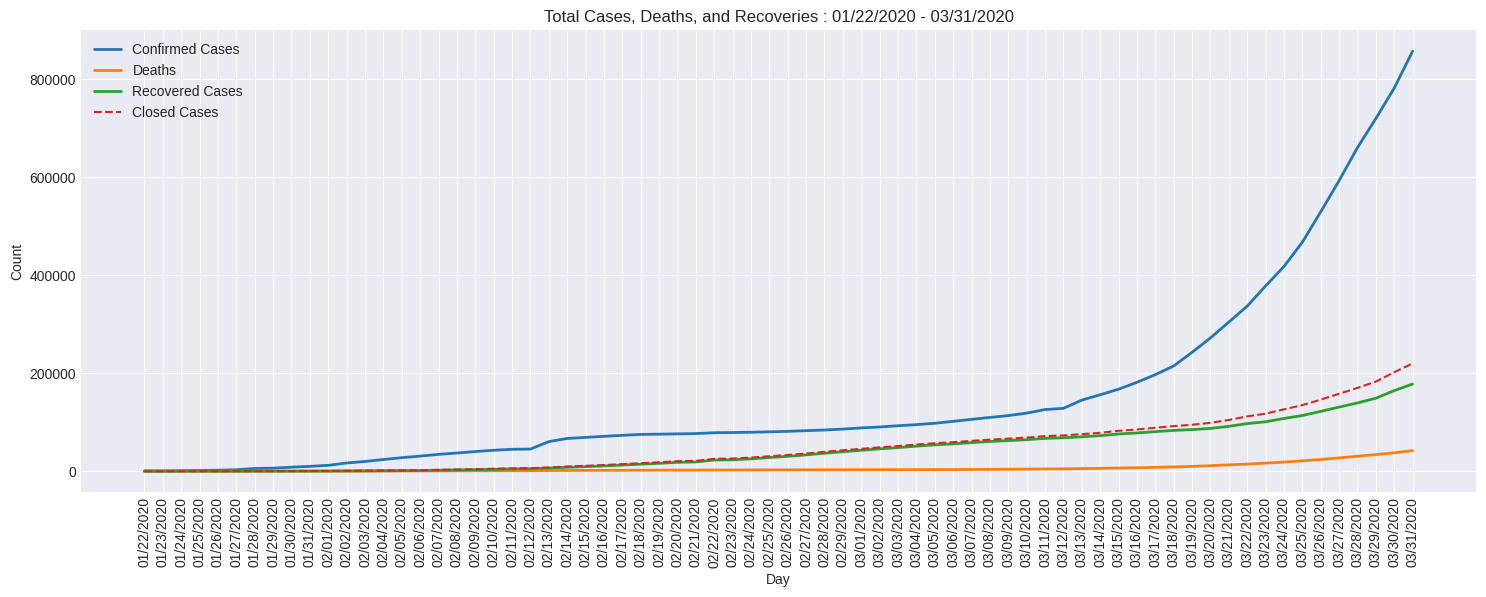

In [12]:
plt.figure(figsize = [18,6])
plt.plot(df_date_tots['Confirmed'], label = "Confirmed Cases", linewidth=2)
plt.plot(df_date_tots['Deaths'], label    = "Deaths", linewidth=2)
plt.plot(df_date_tots['Recovered'], label = "Recovered Cases", linewidth=2)
plt.plot(df_date_tots['Closed Cases'],label="Closed Cases",linestyle='--')

plt.legend()
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation = 90);
start_date = str(date_lst[0]);
fin_date   = str(date_lst[len(date_lst) -1])
plt.title("Total Cases, Deaths, and Recoveries : " + start_date + " - " + fin_date);
plt.grid(True)
plt.show()


All of the three curves seem to be exponential (start of logistic curve). The confirmed cases was obviously higher than the deaths and recovered cases. The rate of the the recovered cases seems to be higher than that of the death curve.

### 6. Create one **plot** showing the trend of number of active cases and closed cases

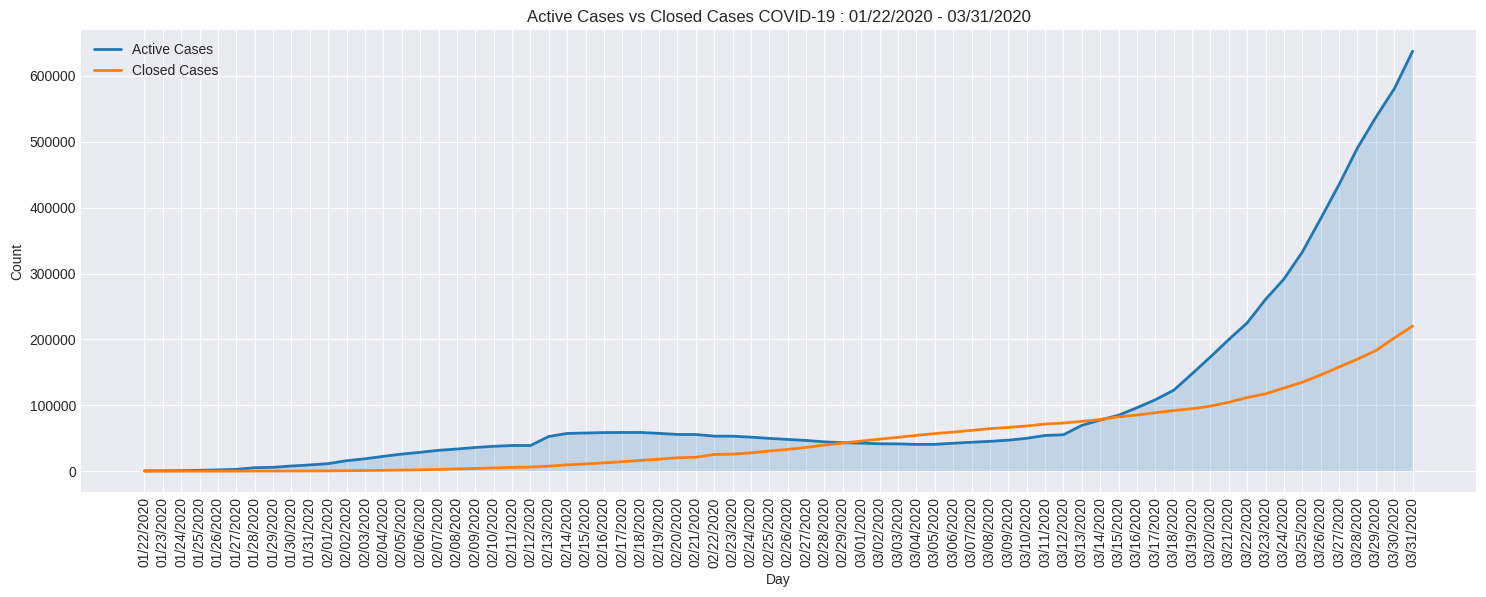

In [13]:
plt.figure(figsize = [18,6])
plt.plot(df_date_tots['Active Cases'], label = "Active Cases", linewidth=2)
plt.plot(df_date_tots['Closed Cases'], label = "Closed Cases", linewidth=2)
plt.fill_between(range(len(df_date_tots)),df_date_tots['Active Cases'],alpha=0.2)
plt.legend();
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation = 90)
start_date = str(date_lst[0])
fin_date   = str(date_lst[len(date_lst) -1])
plt.title("Active Cases vs Closed Cases COVID-19 : " + start_date + " - " + fin_date);
plt.grid(True)
plt.show()

The number of active cases is higher than the number of closed cases as of yet.

### 7. Growth Factor

**Growth factor** is the factor by which a quantity multiplies itself over time. In the below cell, we calculate the GF of the confirmed, recovered and death cases.


In [14]:
growth_len_lst = len(date_lst) - 1
confirmed_lst = df_date_tots["Confirmed"]
death_lst = df_date_tots["Deaths"]
recovered_lst = df_date_tots["Recovered"]
confGF_lst = []
deathsGF_lst = []
recovGF_lst = []
for i in range(growth_len_lst):
    confirmedGF = (confirmed_lst[i+1] / confirmed_lst[i]
    if confirmed_lst[i] != 0 else np.nan)
    confGF_lst.append(confirmedGF)

    deathGF = (death_lst[i+1] / death_lst[i]if death_lst[i] != 0 else np.nan)
    deathsGF_lst.append(deathGF)
    recoveredGF = (recovered_lst[i+1] / recovered_lst[i]if recovered_lst[i] != 0 else np.nan)
    recovGF_lst.append(recoveredGF)

print("Sample Confirmed GF:", confGF_lst[:10])
print("Sample Death GF:", deathsGF_lst[:10])
print("Sample Recovered GF:", recovGF_lst[:10])

Sample Confirmed GF: [np.float64(1.1765765765765765), np.float64(1.44104134762634), np.float64(1.5281615302869287), np.float64(1.4728789986091795), np.float64(1.381964117091596), np.float64(1.9057055005124701), np.float64(1.1052348512011474), np.float64(1.3357664233576643), np.float64(1.2052216150576807), np.float64(1.212896725440806)]
Sample Death GF: [np.float64(1.0588235294117647), np.float64(1.4444444444444444), np.float64(1.6153846153846154), np.float64(1.3333333333333333), np.float64(1.4642857142857142), np.float64(1.5975609756097562), np.float64(1.015267175572519), np.float64(1.2857142857142858), np.float64(1.2456140350877194), np.float64(1.215962441314554)]
Sample Recovered GF: [np.float64(1.0714285714285714), np.float64(1.2), np.float64(1.0833333333333333), np.float64(1.3333333333333333), np.float64(1.1730769230769231), np.float64(1.7540983606557377), np.float64(1.1775700934579438), np.float64(1.1349206349206349), np.float64(1.5524475524475525), np.float64(1.2792792792792793)]

/tmp/ipykernel_2351/335466941.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if confirmed_lst[i] != 0 else np.nan)
/tmp/ipykernel_2351/335466941.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  confirmedGF = (confirmed_lst[i+1] / confirmed_lst[i]
/tmp/ipykernel_2351/335466941.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  deathGF = (death_lst[i+1] / death_lst[i]if death_lst[i] != 0 else np.nan)
/tmp/ipykernel_2351/335

### 8. Create one plot showing the Growth factor of confirmed, recovered and death cases wrt days

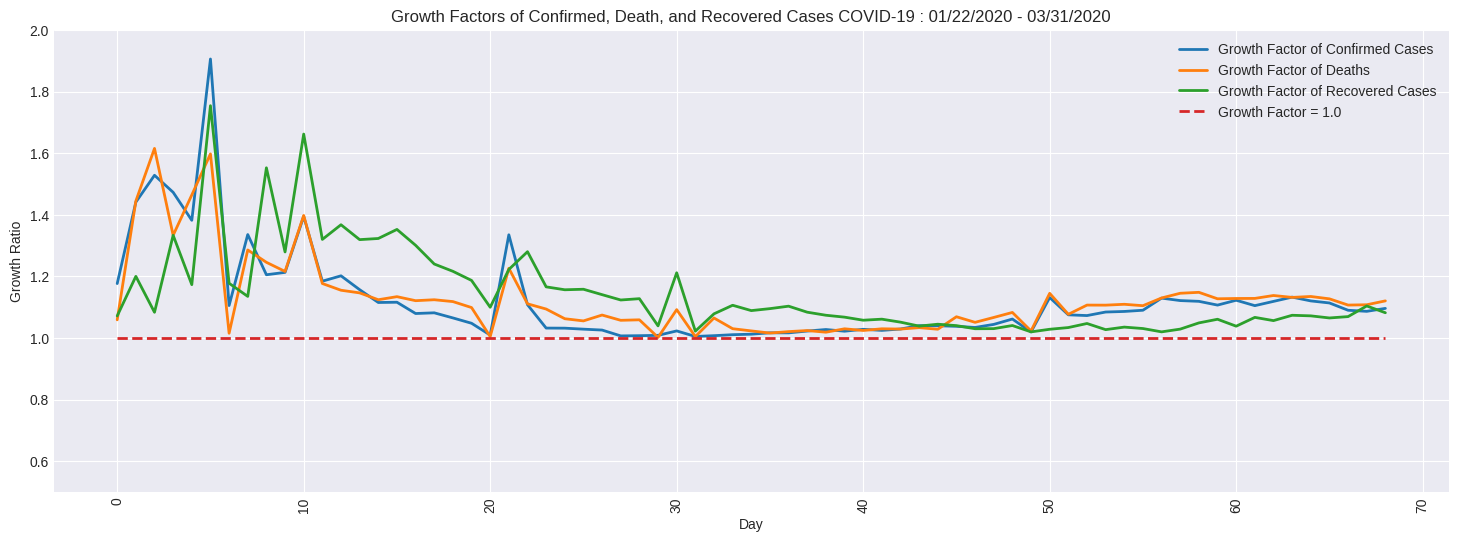

In [15]:
plt.figure(figsize = [18,6])
plt.plot(confGF_lst, label = "Growth Factor of Confirmed Cases", linewidth=2)
plt.plot(deathsGF_lst, label = "Growth Factor of Deaths", linewidth=2)
plt.plot(recovGF_lst, label = "Growth Factor of Recovered Cases", linewidth=2)
x = [1] * growth_len_lst
plt.plot(x, label = "Growth Factor = 1.0", linestyle='--',linewidth=2)

#plt.grid()
plt.grid(True)
plt.legend()
plt.xlabel("Day")
plt.ylabel("Growth Ratio")
plt.ylim(0.5,2)
plt.xticks(rotation = 90)
start_date = str(date_lst[0])
fin_date   = str(date_lst[len(date_lst) -1])
plt.title("Growth Factors of Confirmed, Death, and Recovered Cases COVID-19 : " +start_date +" - " +fin_date)
plt.show()

# **Part 2 - Prediction Using Linear Regression**

#### To make our data to be compatible with *sklearn* format, create a new column called “Days since” which tracks the number of days since the initial date.

In [16]:
days_since_lst = []
for i in range(len(date_lst)):
    days_since_lst.append(i)
df_date_tots["Days Since:"] = days_since_lst
df_date_tots = df_date_tots[["Days Since:", "Confirmed", "Deaths", "Recovered", "Active Cases", "Closed Cases"]]
print(df_date_tots.head())
print("\nShape:", df_date_tots.shape)

            Days Since:  Confirmed  Deaths  Recovered  Active Cases  \
01/22/2020            0      555.0    17.0       28.0         510.0   
01/23/2020            1      653.0    18.0       30.0         605.0   
01/24/2020            2      941.0    26.0       36.0         879.0   
01/25/2020            3     1438.0    42.0       39.0        1357.0   
01/26/2020            4     2118.0    56.0       52.0        2010.0   

            Closed Cases  
01/22/2020          45.0  
01/23/2020          48.0  
01/24/2020          62.0  
01/25/2020          81.0  
01/26/2020         108.0  

Shape: (70, 6)


### 8. Take the earliest 85% of the dates as **train** and the rest as **test**

In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

X = np.array(df_date_tots["Days Since:"]).reshape(-1,1)
y = np.array(df_date_tots["Confirmed"])

split_idx = int(len(X) * 0.85)

X_train = X[:split_idx]
X_test  = X[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

print("Train Size:", len(X_train))
print("Test Size :", len(X_test))

Train Size: 59
Test Size : 11


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.15,
                                                    shuffle = False)
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (59, 1)
Test Shape : (11, 1)


### 9. We can try different regression and regularizations we have seen before

#### 9.1 Linear Regression

In [19]:
lin_model = LinearRegression(fit_intercept = True)
lin_model.fit(X_train, y_train)
test_lin_pred = lin_model.predict(X_test)
lin_pred = lin_model.predict(X)

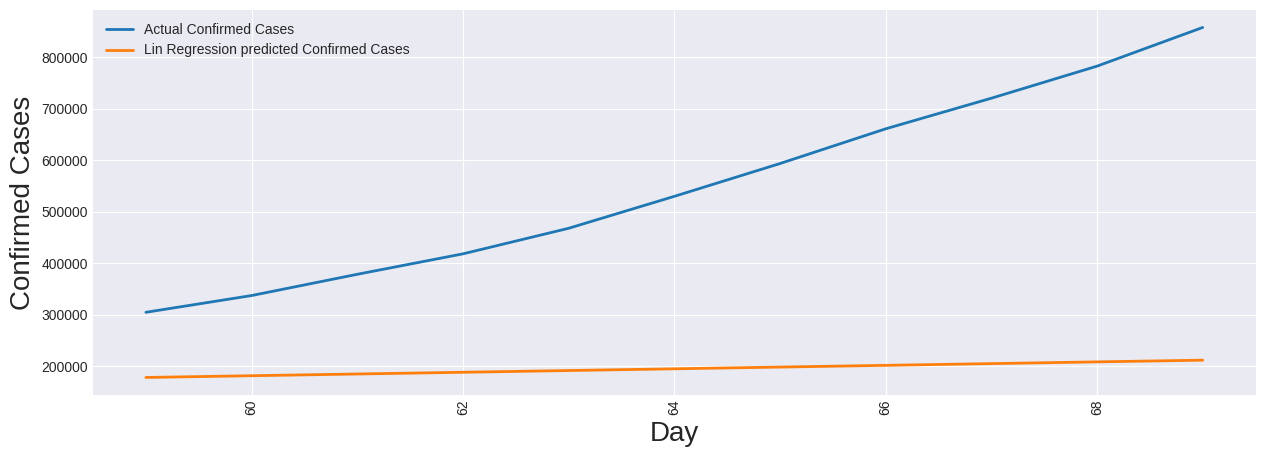

MAE: 194743.629748685
MSE: 38037881873.60582


In [20]:
plt.figure(figsize = [15,5])
# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases",linewidth=2)
# plotting the predicited values for the future days
plt.plot(X_test,
         test_lin_pred,
         label = "Lin Regression predicted Confirmed Cases",linewidth=2)
plt.grid(True);
plt.legend();
plt.xlabel("Day", size = 20)
plt.ylabel("Confirmed Cases", size=20)
plt.xticks(rotation = 90)
plt.show()

print('MAE:', mean_absolute_error (test_lin_pred, X_test))
print('MSE:', mean_squared_error  (test_lin_pred, X_test))

#### Polynomial Regression

In [21]:
poly = PolynomialFeatures(degree=4)
poly_X_train = poly.fit_transform(X_train)
poly_X_test  = poly.fit_transform(X_test)
poly_X = poly.fit_transform(X)

In [22]:
linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(poly_X_train, y_train)
test_poly_pred = linear_model.predict(poly_X_test)
poly_pred = linear_model.predict(poly_X)


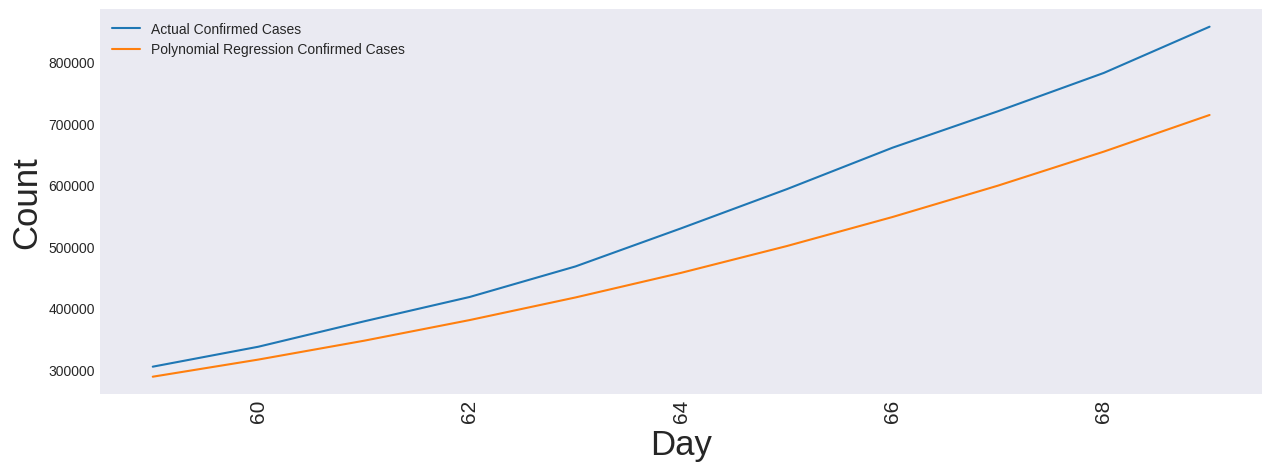

MAE: 75180.82275977643
MSE: 7618807855.010148
RMSE: 87285.78266252842


In [23]:
plt.figure(figsize = [15,5])

# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")

# plotting the predicited values for the future days
plt.plot(X_test,
         test_poly_pred,
         label = "Polynomial Regression Confirmed Cases")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15);
plt.show()

print('MAE:', mean_absolute_error(test_poly_pred, y_test))
print('MSE:',mean_squared_error(test_poly_pred, y_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_poly_pred)))

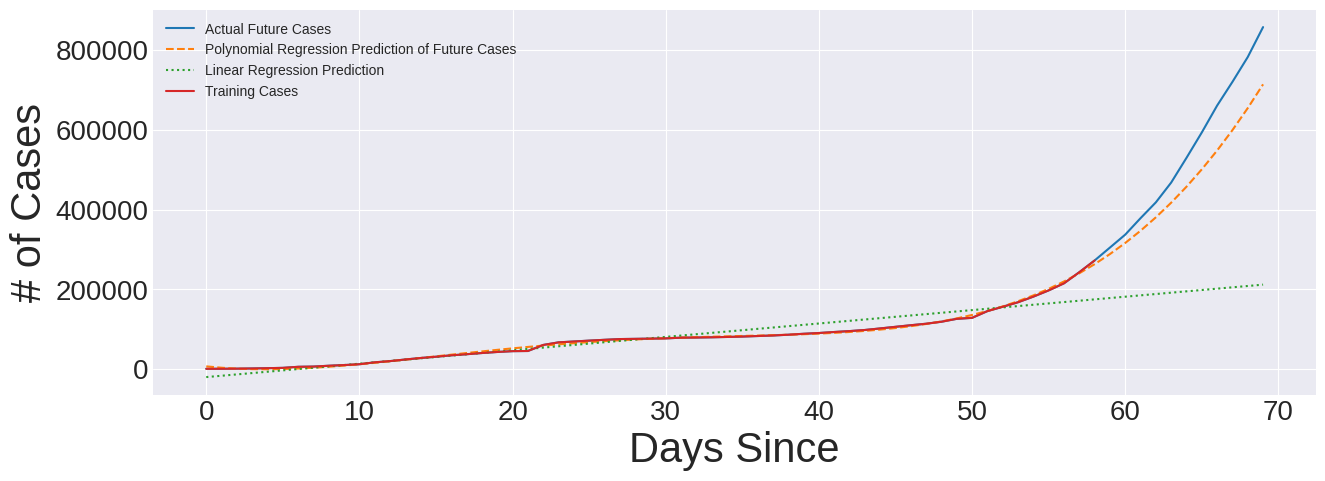

In [24]:
plt.figure(figsize=(15, 5))
plt.plot(X,
         y,
         label = 'Actual Future Cases')

plt.plot(X,
         poly_pred,
         label = 'Polynomial Regression Prediction of Future Cases',
         linestyle = "dashed")

plt.plot(X,
         lin_pred,
         label='Linear Regression Prediction',
         linestyle="dotted")

plt.plot(X_train,
         y_train,
         label = 'Training Cases')

plt.xlabel('Days Since', size = 30)
plt.ylabel('# of Cases', size = 30)
plt.legend()
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()

### 9.2 Ridge Regression

In [25]:
tol      = [1e-5, 1e-4, 1e-3, 1e-2]
alpha_1  = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
alpha_2  = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
lambda_1 = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
lambda_2 = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]

bayesian_grid = {
    'tol': tol,
    'alpha_1': alpha_1,
    'alpha_2': alpha_2,
    'lambda_1': lambda_1,
    'lambda_2': lambda_2
}

bayesian = BayesianRidge(fit_intercept=True)

bayesian_search = RandomizedSearchCV(
    bayesian,
    bayesian_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    return_train_score=True,
    n_jobs=-1,
    n_iter=60,
    verbose=1
)

bayesian_search.fit(X_train, y_train)

print(bayesian_search.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
{'tol': 0.0001, 'lambda_2': 0.0001, 'lambda_1': 0.0001, 'alpha_2': 1e-07, 'alpha_1': 1e-08}


In [28]:
y_test_ridge_pred = bayesian_search.predict(X_test);
y_ridge_pred = bayesian_search.predict(X);
print("MAE:", mean_absolute_error(y_test, y_test_ridge_pred))
print("MSE:", mean_squared_error(y_test, y_test_ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_ridge_pred)))

MAE: 355397.8298239037
MSE: 154594155582.95468
RMSE: 393184.6329435507


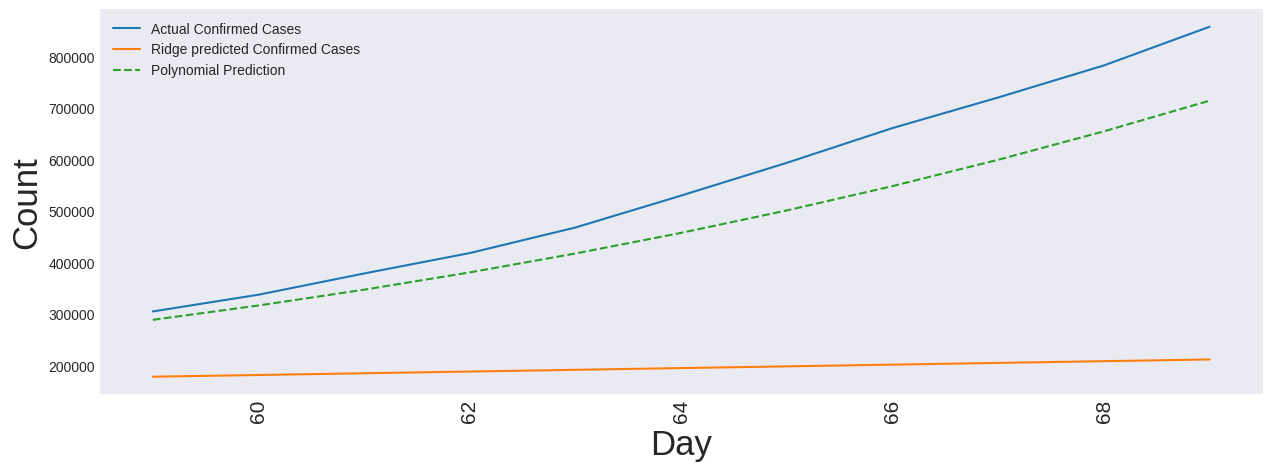

MAE: 194442.89744882358
MSE: 37920264490.62725
RMSE: 393184.6329435507


In [30]:
plt.figure(figsize = [15,5])

# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")

# plotting the predicited values for the future days
plt.plot(X_test,
         y_test_ridge_pred,
         label = "Ridge predicted Confirmed Cases")

plt.plot(X_test,
         test_poly_pred,
         label="Polynomial Prediction",
         linestyle="dashed")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15);
plt.show()

print('MAE:', mean_absolute_error (y_test_ridge_pred, X_test))
print('MSE:', mean_squared_error  (y_test_ridge_pred, X_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_ridge_pred)))

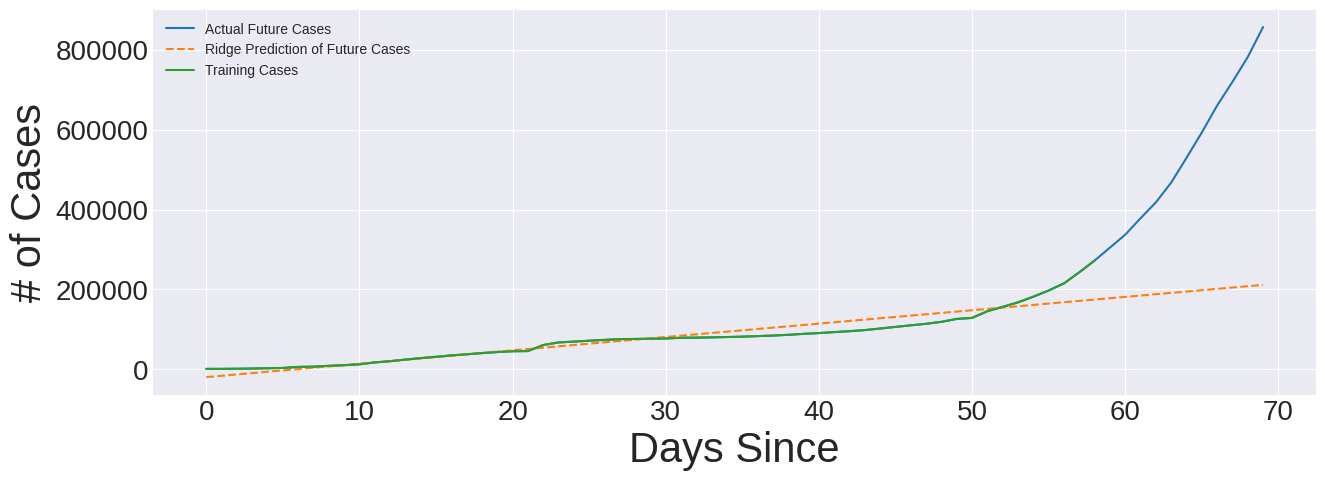

In [31]:
plt.figure(figsize=(15, 5))
plt.plot(X,
         y,
         label = 'Actual Future Cases')
plt.plot(X,
         y_ridge_pred,
         label = 'Ridge Prediction of Future Cases',
         linestyle = "dashed")
plt.plot(X_train,
         y_train,
         label = 'Training Cases')

#plt.title('# of Coronavirus Cases Over Time', size=30)
plt.xlabel('Days Since', size = 30)
plt.ylabel('# of Cases', size = 30)
plt.legend()
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()

#### Polynomial Ridge Regression

In [32]:
bayesian_search_poly = RandomizedSearchCV(bayesian,
                                     bayesian_grid,
                                     scoring='neg_mean_squared_error',
                                     cv=5,
                                     return_train_score=True,
                                     n_jobs=-1,
                                     n_iter=60,
                                     verbose=1)


In [33]:
bayesian_search_poly.fit(poly_X_train, y_train);
print(bayesian_search_poly.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
{'tol': 0.01, 'lambda_2': 0.0001, 'lambda_1': 0.0001, 'alpha_2': 1e-07, 'alpha_1': 1e-06}


In [34]:
bayesian_poly_confirmed = bayesian_search_poly.best_estimator_
test_poly_bayesian_pred = bayesian_poly_confirmed.predict(poly_X_test)
bayesian_poly_pred = bayesian_poly_confirmed.predict(poly_X)
print("MAE:", mean_absolute_error(y_test, test_poly_bayesian_pred))
print("MSE:", mean_squared_error(y_test, test_poly_bayesian_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_poly_bayesian_pred)))

MAE: 249931.0180453914
MSE: 81460989288.26611
RMSE: 285413.71601285407


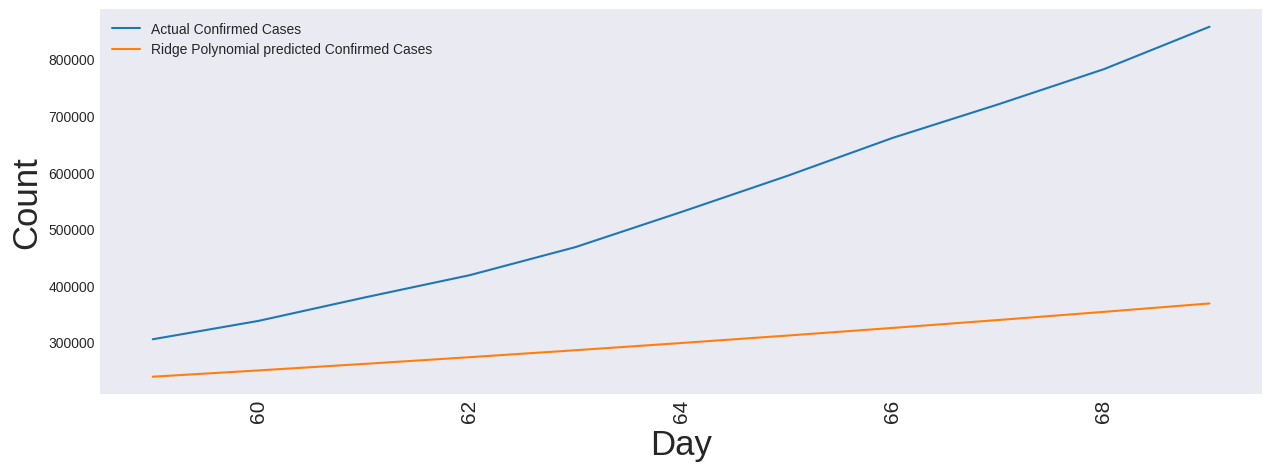

MAE: 249931.0180453914
MSE: 81460989288.26611


In [35]:
plt.figure(figsize = [15,5])

# plotting the actual values for the future days
plt.plot(X_test,
         y_test,
         label = "Actual Confirmed Cases")

# plotting the predicited values for the future days
plt.plot(X_test,
         test_poly_bayesian_pred,
         label = "Ridge Polynomial predicted Confirmed Cases")
plt.grid();
plt.legend();
plt.xlabel("Day", size = 25)
plt.ylabel("Count", size = 25)
plt.xticks(rotation = 90, size = 15)
plt.show()

print ('MAE:', mean_absolute_error(test_poly_bayesian_pred, y_test))
print ('MSE:', mean_squared_error (test_poly_bayesian_pred, y_test))

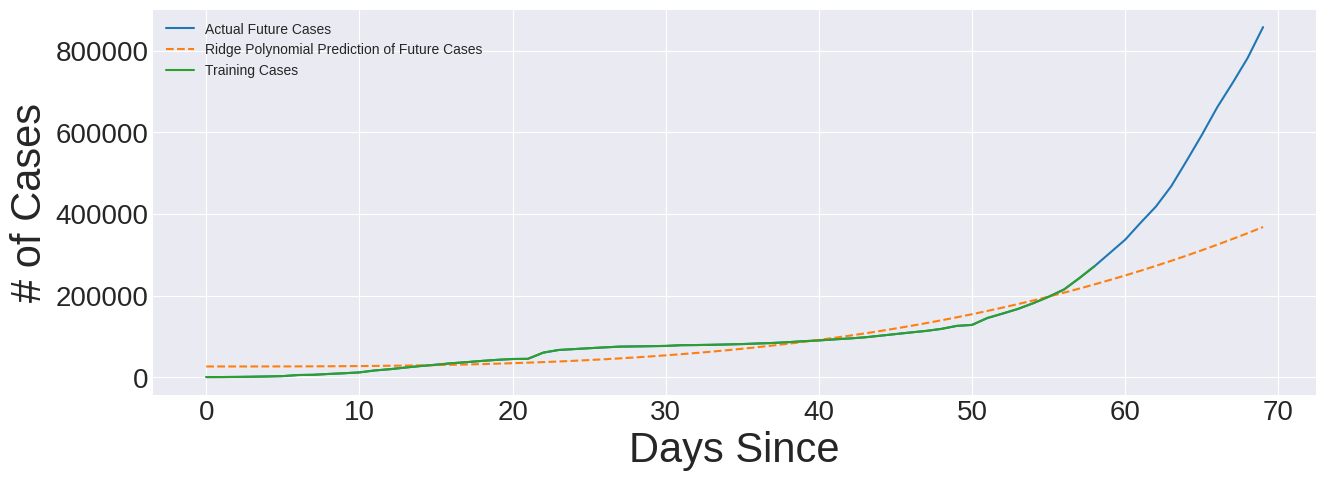

In [36]:
plt.figure(figsize=(15, 5))
plt.plot(X,
         y,
         label = 'Actual Future Cases')
plt.plot(X,
         bayesian_poly_pred,
         label = 'Ridge Polynomial Prediction of Future Cases',
         linestyle = "dashed")
plt.plot(X_train,
         y_train,
         label = 'Training Cases')

#plt.title('# of Coronavirus Cases Over Time', size=30)
plt.xlabel('Days Since', size = 30)
plt.ylabel('# of Cases', size = 30)
#plt.grid()
plt.legend()
plt.xticks(size=20)
plt.yticks(size=20)
plt.show()

In [37]:
print("Polynomial Regression ")
print('\tMAE:', mean_absolute_error(test_poly_pred, y_test))
print('\tMSE:',mean_squared_error(test_poly_pred, y_test))

print("\nRidge Polynomial Regression ")
print ('\tMAE:', mean_absolute_error(test_poly_bayesian_pred, y_test))
print ('\tMSE:', mean_squared_error (test_poly_bayesian_pred, y_test))

Polynomial Regression 
	MAE: 75180.82275977643
	MSE: 7618807855.010148

Ridge Polynomial Regression 
	MAE: 249931.0180453914
	MSE: 81460989288.26611


From Mean Absolute Error and Mean Squared Error values, Ridge Polynomial Regression Model seems to be the best model.